
# Interactive Sales Dashboard

### Project Features
- Clean and modular coding structure
- Seaborn statistical visualizations
- Interactive Plotly charts
- Correlation heatmaps
- Professional dashboard layout
- Reusable plotting functions
- Export-ready visualizations

---
### Dataset
This project uses a sales dataset containing:
- Product information
- Regional sales
- Customer data
- Quantity and pricing details


In [1]:
!pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ================================
# IMPORT REQUIRED LIBRARIES
# ================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from pathlib import Path


In [3]:
# ================================
# GLOBAL CONFIGURATION
# ================================

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

VISUALIZATION_DIR = Path("visualizations")
VISUALIZATION_DIR.mkdir(exist_ok=True)

COLOR_PALETTE = "Set2"


In [4]:
# ================================
# LOAD DATASET
# ================================

DATA_PATH = "sales_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [5]:
# ================================
# DATA PREPROCESSING
# ================================

def preprocess_data(dataframe: pd.DataFrame) -> pd.DataFrame:
    '''
    Clean and preprocess sales dataset.
    '''

    dataframe = dataframe.copy()

    dataframe["Date"] = pd.to_datetime(dataframe["Date"])

    dataframe["Month"] = dataframe["Date"].dt.strftime("%b")

    return dataframe


df = preprocess_data(df)

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         100 non-null    datetime64[us]
 1   Product      100 non-null    str           
 2   Quantity     100 non-null    int64         
 3   Price        100 non-null    int64         
 4   Customer_ID  100 non-null    str           
 5   Region       100 non-null    str           
 6   Total_Sales  100 non-null    int64         
 7   Month        100 non-null    str           
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 6.4 KB


## 1. Sales Trend Analysis

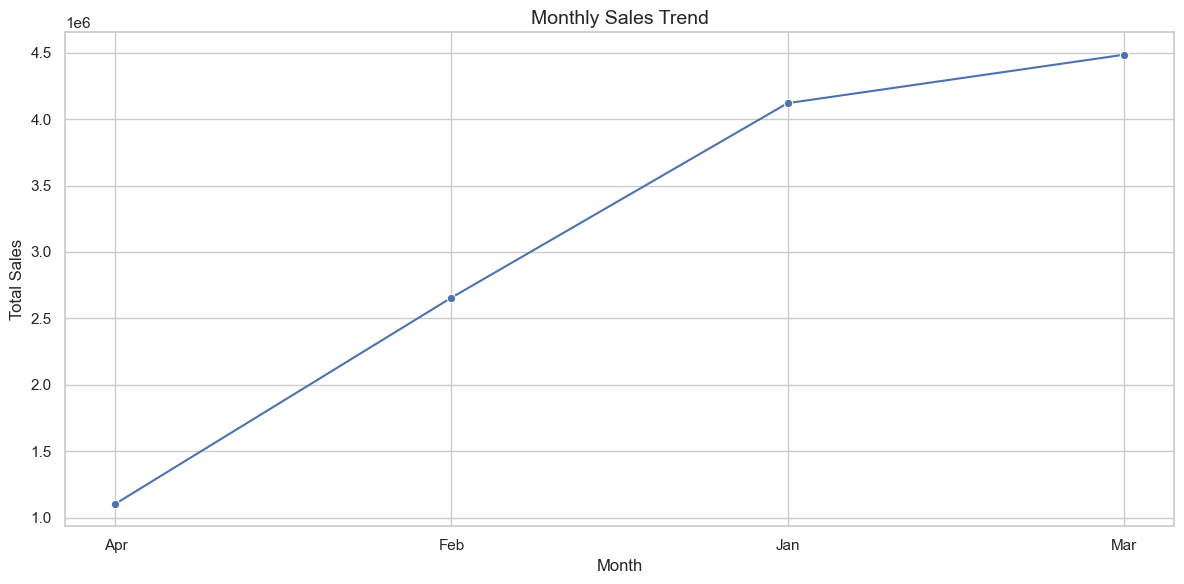

In [6]:
# ================================
# SALES TREND LINE CHART
# ================================

def plot_sales_trend(dataframe: pd.DataFrame) -> None:
    '''
    Plot monthly sales trend.
    '''

    monthly_sales = dataframe.groupby("Month")["Total_Sales"].sum().reset_index()

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=monthly_sales,
        x="Month",
        y="Total_Sales",
        marker="o"
    )

    plt.title("Monthly Sales Trend")
    plt.xlabel("Month")
    plt.ylabel("Total Sales")

    plt.tight_layout()

    plt.savefig(VISUALIZATION_DIR / "sales_trend.png")

    plt.show()


plot_sales_trend(df)


## 2. Product Performance Analysis

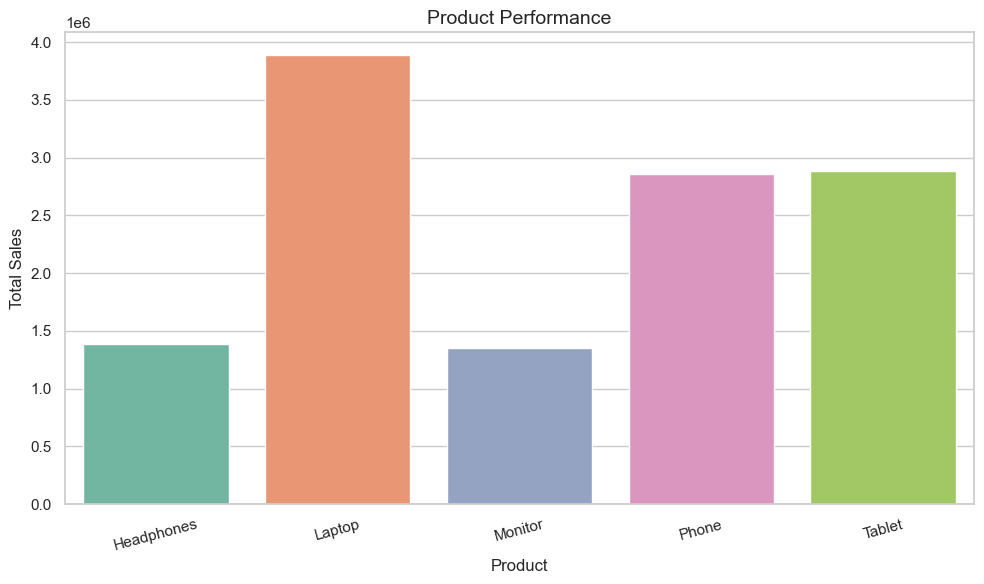

In [7]:
# ================================
# BAR CHART - PRODUCT PERFORMANCE
# ================================

def plot_product_sales(dataframe: pd.DataFrame) -> None:
    '''
    Plot product-wise sales comparison.
    '''

    product_sales = dataframe.groupby("Product")["Total_Sales"].sum().reset_index()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=product_sales,
        x="Product",
        y="Total_Sales",
        palette=COLOR_PALETTE
    )

    plt.title("Product Performance")
    plt.xlabel("Product")
    plt.ylabel("Total Sales")

    plt.xticks(rotation=15)

    plt.tight_layout()

    plt.savefig(VISUALIZATION_DIR / "product_sales.png")

    plt.show()


plot_product_sales(df)


## 3. Statistical Visualization - Box Plot

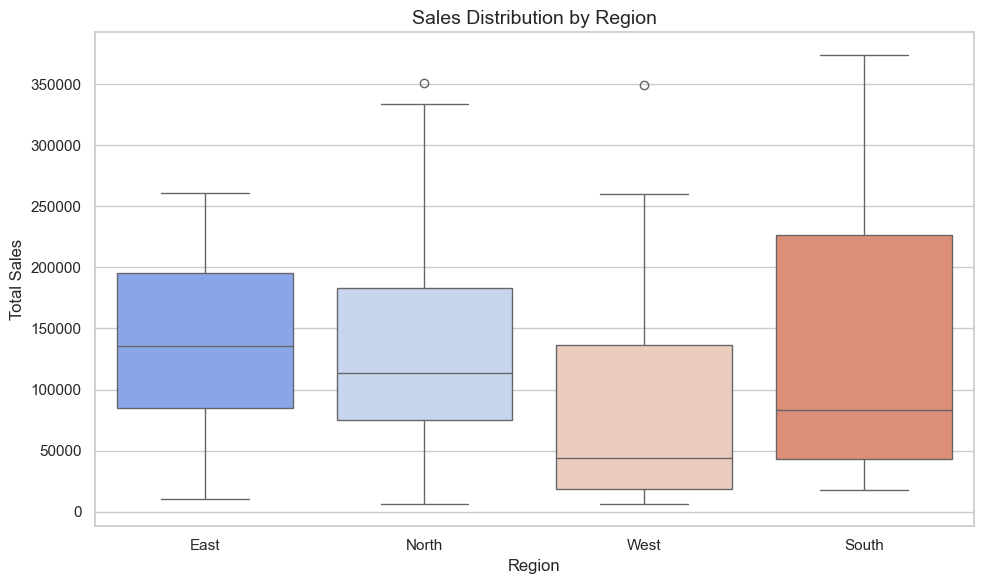

In [8]:
# ================================
# BOX PLOT - SALES DISTRIBUTION
# ================================

def plot_sales_distribution(dataframe: pd.DataFrame) -> None:
    '''
    Visualize sales distribution across regions.
    '''

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=dataframe,
        x="Region",
        y="Total_Sales",
        palette="coolwarm"
    )

    plt.title("Sales Distribution by Region")
    plt.xlabel("Region")
    plt.ylabel("Total Sales")

    plt.tight_layout()

    plt.savefig(VISUALIZATION_DIR / "boxplot_sales.png")

    plt.show()


plot_sales_distribution(df)


## 4. Violin Plot Analysis

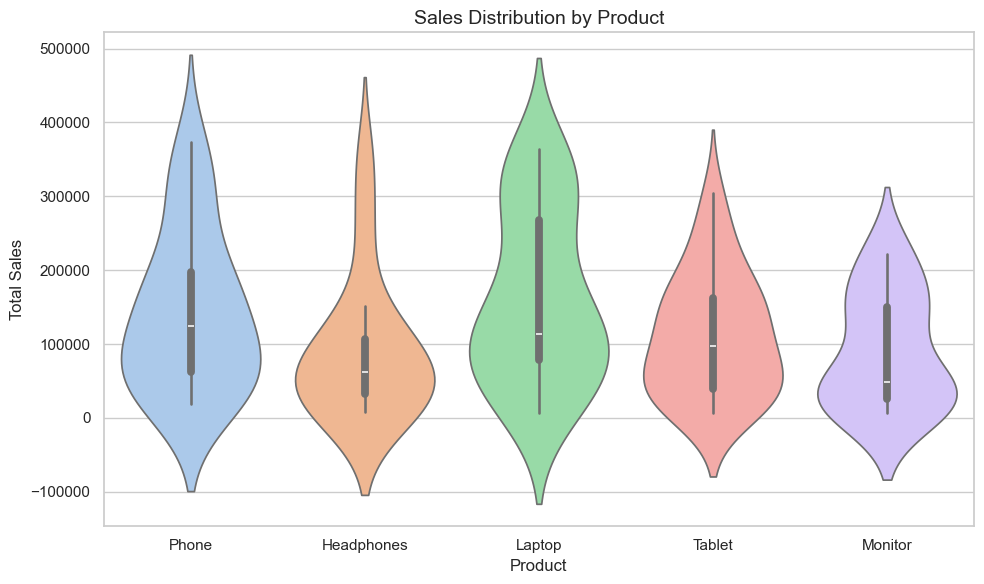

In [9]:
# ================================
# VIOLIN PLOT
# ================================

def plot_violin_chart(dataframe: pd.DataFrame) -> None:
    '''
    Create violin plot for product sales.
    '''

    plt.figure(figsize=(10, 6))

    sns.violinplot(
        data=dataframe,
        x="Product",
        y="Total_Sales",
        palette="pastel"
    )

    plt.title("Sales Distribution by Product")
    plt.xlabel("Product")
    plt.ylabel("Total Sales")

    plt.tight_layout()

    plt.savefig(VISUALIZATION_DIR / "violin_plot.png")

    plt.show()


plot_violin_chart(df)


## 5. Correlation Heatmap

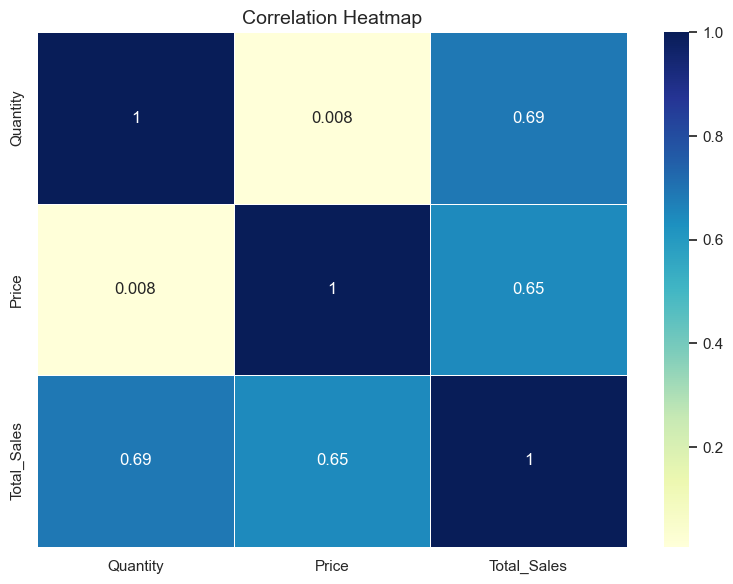

In [10]:
# ================================
# HEATMAP
# ================================

def plot_correlation_heatmap(dataframe: pd.DataFrame) -> None:
    '''
    Create correlation heatmap for numerical features.
    '''

    numeric_df = dataframe.select_dtypes(include=np.number)

    correlation_matrix = numeric_df.corr()

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap="YlGnBu",
        linewidths=0.5
    )

    plt.title("Correlation Heatmap")

    plt.tight_layout()

    plt.savefig(VISUALIZATION_DIR / "heatmap.png")

    plt.show()


plot_correlation_heatmap(df)


## 6. Multi-Plot Dashboard

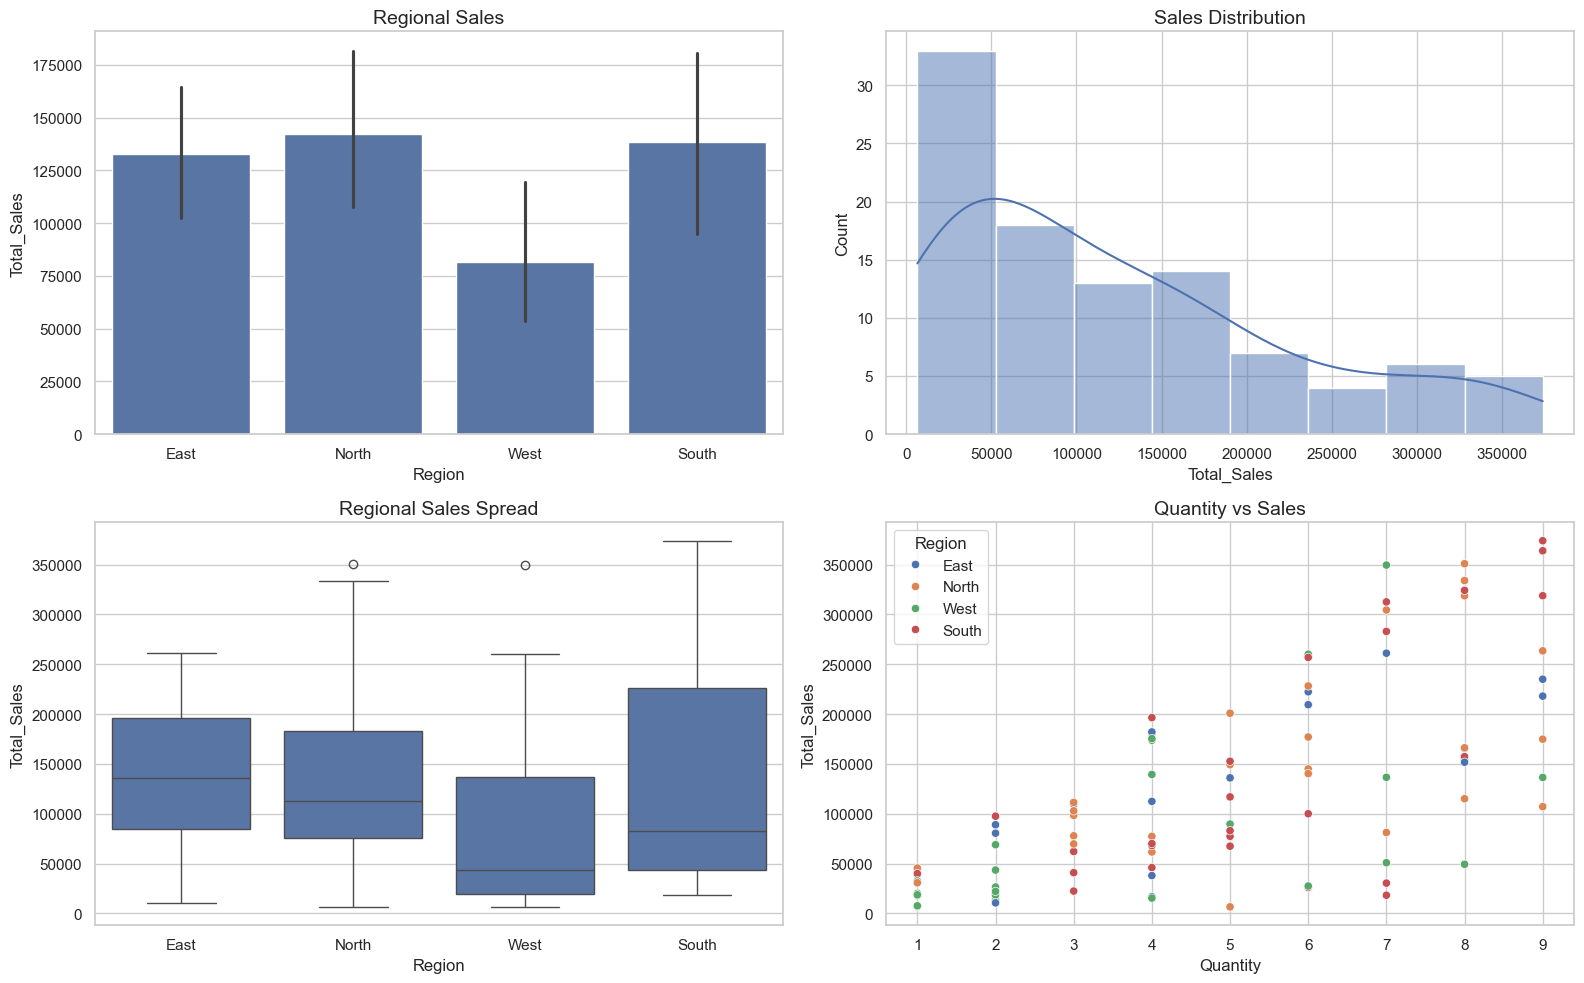

In [11]:
# ================================
# MULTI-PLOT DASHBOARD
# ================================

def create_dashboard(dataframe: pd.DataFrame) -> None:
    '''
    Create 2x2 subplot dashboard.
    '''

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Chart 1
    sns.barplot(
        data=dataframe,
        x="Region",
        y="Total_Sales",
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Regional Sales")

    # Chart 2
    sns.histplot(
        dataframe["Total_Sales"],
        kde=True,
        ax=axes[0, 1]
    )
    axes[0, 1].set_title("Sales Distribution")

    # Chart 3
    sns.boxplot(
        data=dataframe,
        x="Region",
        y="Total_Sales",
        ax=axes[1, 0]
    )
    axes[1, 0].set_title("Regional Sales Spread")

    # Chart 4
    sns.scatterplot(
        data=dataframe,
        x="Quantity",
        y="Total_Sales",
        hue="Region",
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Quantity vs Sales")

    plt.tight_layout()

    plt.savefig(VISUALIZATION_DIR / "dashboard_overview.png")

    plt.show()


create_dashboard(df)


## 7. Interactive Plotly Dashboard

In [12]:
# ==========================================
# INTERACTIVE PLOTLY DASHBOARD
# ==========================================

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "browser"

# Create subplot layout
interactive_fig = make_subplots(
    rows=2,
    cols=2,

    subplot_titles=(
        "Monthly Sales Trend",
        "Regional Sales",
        "Product Distribution",
        "Quantity vs Sales"
    ),

    specs=[
        [{"type": "scatter"}, {"type": "bar"}],
        [{"type": "domain"}, {"type": "scatter"}]
    ]
)

# ==========================================
# MONTHLY SALES TREND
# ==========================================

monthly_sales = (
    df.groupby("Month")["Total_Sales"]
    .sum()
    .reset_index()
)

interactive_fig.add_trace(
    go.Scatter(
        x=monthly_sales["Month"],
        y=monthly_sales["Total_Sales"],
        mode="lines+markers",
        name="Monthly Sales"
    ),
    row=1,
    col=1
)

# ==========================================
# REGIONAL SALES
# ==========================================

region_sales = (
    df.groupby("Region")["Total_Sales"]
    .sum()
    .reset_index()
)

interactive_fig.add_trace(
    go.Bar(
        x=region_sales["Region"],
        y=region_sales["Total_Sales"],
        name="Regional Sales"
    ),
    row=1,
    col=2
)

# ==========================================
# PRODUCT DISTRIBUTION PIE CHART
# ==========================================

product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .reset_index()
)

interactive_fig.add_trace(
    go.Pie(
        labels=product_sales["Product"],
        values=product_sales["Total_Sales"],
        name="Product Distribution"
    ),
    row=2,
    col=1
)

# ==========================================
# QUANTITY VS SALES SCATTER PLOT
# ==========================================

interactive_fig.add_trace(
    go.Scatter(
        x=df["Quantity"],
        y=df["Total_Sales"],
        mode="markers",
        marker=dict(size=10),
        text=df["Region"],
        hovertemplate=
        "<b>Region:</b> %{text}<br>" +
        "<b>Quantity:</b> %{x}<br>" +
        "<b>Sales:</b> %{y}<extra></extra>",
        name="Quantity vs Sales"
    ),
    row=2,
    col=2
)

# ==========================================
# DASHBOARD LAYOUT
# ==========================================

interactive_fig.update_layout(
    title="Interactive Sales Dashboard",
    height=800,
    width=1200,
    template="plotly_white",
    showlegend=True
)

interactive_fig.show()